# Piecewise-Linear Functions

Many relationships in engineering models are known only as a **table**: a pump
curve read off a manufacturer's datasheet, a tiered electricity tariff, a
property fit, a compressor map. `Model.piecewise` lets you declare such a
relationship directly,

$$
y = f(x), \qquad f \text{ the piecewise-linear interpolant of } (b_0, v_0), \dots, (b_{n-1}, v_{n-1}),
$$

and discopt lowers it to an exact mixed-integer linear representation. This is the
classical *separable programming* device of special ordered sets
{cite:p}`BealeTomlin1970` and of the convex-combination and incremental models
{cite:p}`Dantzig1960,MarkowitzManne1957`; the modern treatment of the encodings is
{cite:t}`Vielma2010` and the survey {cite:t}`Vielma2015`.

This notebook covers:

1. declaring a piecewise-linear function and using it in a model,
2. why the result is **exact** (and therefore certifiable),
3. the four encodings (`method=`) and how they compare,
4. the domain rule: the input must live inside the breakpoint span,
5. array and composite inputs,
6. what `piecewise` is **not**: a PWL approximation of a nonlinear term.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import discopt.modeling as dm

## 1. A first example: a nonconvex tabulated cost

Declare an input variable with bounds, pass breakpoints and values, and get back an
output variable `y` that can be used anywhere an expression can.

In [2]:
b = [0.0, 1.0, 2.5, 3.0, 4.0, 6.0]
v = [1.0, 3.0, -0.5, 2.0, 2.0, -1.0]

m = dm.Model("first_pwl")
x = m.continuous("x", lb=0.0, ub=6.0)
y = m.piecewise(x, b, v, name="f")  # y == f(x), exactly
m.minimize(y + 0.4 * x)

r = m.solve()
print(r.status, "certified:", r.gap_certified)
print(f"x* = {r.value(x):.4f}   f(x*) = {r.value(y):.4f}   objective = {r.objective:.4f}")

optimal certified: True
x* = 2.5000   f(x*) = -0.5000   objective = 0.5000


The objective $f(x) + 0.4x$ is nonconvex with two local minima, $x=0$ (value 1.0)
and $x=2.5$ (value 0.5). A local method started near $x=0$ would stop there; the
MILP formulation lets branch-and-bound prove which one is global.

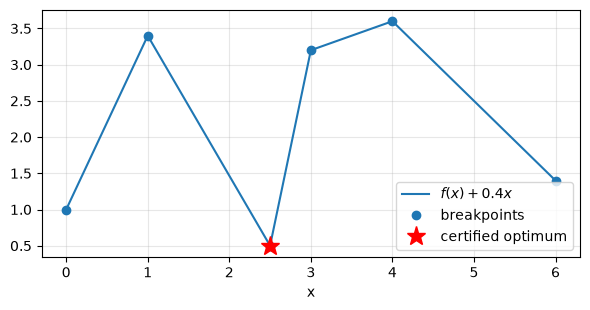

In [3]:
xs = np.linspace(0, 6, 601)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(xs, np.interp(xs, b, v) + 0.4 * xs, label=r"$f(x) + 0.4x$")
ax.plot(b, np.array(v) + 0.4 * np.array(b), "o", color="C0", label="breakpoints")
ax.plot([r.value(x)], [r.objective], "r*", ms=14, label="certified optimum")
ax.set_xlabel("x"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## 2. Exact, not approximate

The table **defines** $f$. Every encoding offered is an exact MILP representation of
the graph $\{(x, f(x)) : b_0 \le x \le b_{n-1}\}$, so at every feasible point
`y == f(x)` — at the breakpoints *and between them*. The easiest way to see it is to
fix $x$ and ask the solver for the smallest and the largest $y$ the rows allow: both
must come back as $f(x)$.

In [4]:
def y_range(t, method):
    out = []
    for sense in ("min", "max"):
        mm = dm.Model()
        xx = mm.continuous("x", lb=t, ub=t)
        yy = mm.piecewise(xx, b, v, method=method)
        (mm.minimize if sense == "min" else mm.maximize)(yy)
        out.append(float(mm.solve().value(yy)))
    return out


probes = [0.0, 0.5, 1.75, 2.5, 2.75, 3.6, 5.1, 6.0]
worst = 0.0
for method in ("disaggregated", "incremental", "log", "sos2"):
    for t in probes:
        lo, hi = y_range(t, method)
        worst = max(worst, abs(lo - np.interp(t, b, v)), abs(hi - np.interp(t, b, v)))
print(f"{4 * len(probes) * 2} solves; max |y - f(x)| over all of them = {worst:.2e}")

64 solves; max |y - f(x)| over all of them = 7.77e-16


Because the model solved *is* the model declared, a certificate on it
(`gap_certified=True`) means exactly what it always means. That is the difference
between declaring a piecewise-linear function and **approximating** a nonlinear one
by a piecewise-linear surrogate — see §6.

## 3. The encodings

All four `method=` values are exact; they differ in size and in the strength of the
LP relaxation that branch-and-bound works with. For $n$ breakpoints:

| `method` (aliases) | binaries | continuous aux | LP strength | reference |
|---|---|---|---|---|
| `"incremental"` (`"inc"`, `"delta"`) — **default** | $n-2$ | $n-1$ | locally ideal | {cite:p}`MarkowitzManne1957` |
| `"disaggregated"` (`"dcc"`) | $n-1$ | $2(n-1)$ | locally ideal | {cite:p}`Croxton2003,Vielma2010` |
| `"log"` (`"logarithmic"`, `"ebd"`) | $\lceil\log_2(n-1)\rceil$ | $n$ | locally ideal | {cite:p}`Vielma2011` |
| `"sos2"` (`"lambda"`) | $n$ after lowering | $n$ | weaker (pairwise SOS2 rows) | {cite:p}`BealeTomlin1970,Dantzig1960` |

* `"log"` enforces the SOS2 adjacency with a Gray code: adjacent segments differ in
  one bit, so each bit splits the breakpoints into a left and right branch
  {cite:p}`Vielma2011`. It reuses the same embedding discopt's AMP solver uses for
  its `convhull_ebd` option; the partitioning idea is also central to
  {cite:t}`Misener2011`.
* `"sos2"` declares an actual SOS2 set (`Model.sos2`) — the route for a user who
  wants the SOS2 relation itself. discopt lowers it at solve time with one binary
  per breakpoint and $O(n^2)$ pairwise exclusion rows, so it is the slowest method
  for long tables. The `.nl`/LP/MPS/GAMS writers refuse SOS relations (they emit no
  SOS section), so for a model you intend to export pick another method: those
  lower to plain linear rows and export like any MILP.
* A two-breakpoint table is a single segment and adds no binary under any method.

In [5]:
from discopt.modeling.core import VarType


def census(n, method):
    mm = dm.Model()
    xx = mm.continuous("x", lb=0, ub=1)
    mm.piecewise(xx, np.linspace(0, 1, n), np.sin(np.linspace(0, 6, n)), method=method)
    nb = sum(var.size for var in mm._variables if var.var_type == VarType.BINARY)
    nc = sum(var.size for var in mm._variables if var.var_type == VarType.CONTINUOUS) - 2
    return nb, nc, len(mm._constraints)


print(f"{'n':>4} {'method':>14} {'binaries':>9} {'cont. aux':>10} {'rows':>5}")
for n in (5, 17, 65):
    for method in ("disaggregated", "incremental", "log", "sos2"):
        nb, nc, nr = census(n, method)
        print(f"{n:4d} {method:>14} {nb:9d} {nc:10d} {nr:5d}")

   n         method  binaries  cont. aux  rows
   5  disaggregated         4          8     7
   5    incremental         3          4     8
   5            log         2          5     7
   5           sos2         0          5     4
  17  disaggregated        16         32    19
  17    incremental        15         16    32
  17            log         4         17    11
  17           sos2         0         17     4
  65  disaggregated        64        128    67
  65    incremental        63         64   128
  65            log         6         65    15
  65           sos2         0         65     4


(For `"sos2"` the binary count shows 0 because the SOS2 row is still a declaration
at this point; the solver lowers it at solve time.)

### Which method is fastest?

Measured, not assumed. `discopt_benchmarks/scripts/piecewise_method_panel.py` builds
seeded random nonconvex tables, runs the four methods **interleaved** on each
instance, and cross-checks that every certified objective agrees (it aborts on any
disagreement). Two classes — a separable PWL-cost MILP with a coupling row
(8 functions, 9/17/33 breakpoints) and a MINLP with a quadratic penalty on the PWL
outputs (4 functions, 9/17 breakpoints). Wall seconds; every run finished
certified and the methods agreed on every objective.

Panel A — seeds 0–2, all four methods (60 runs):

| method | median | mean | sd | shifted geo. mean |
|---|---|---|---|---|
| `incremental` | 0.369 | 1.437 | 2.403 | **0.857** |
| `log` | 0.590 | 1.151 | 1.360 | 0.867 |
| `disaggregated` | 0.715 | 2.902 | 4.626 | 1.427 |
| `sos2` | 2.474 | 9.537 | 11.401 | 4.629 |

Panel B — fresh seeds 3–7, the three fastest (75 runs):

| method | median | mean | sd | shifted geo. mean |
|---|---|---|---|---|
| `incremental` | 0.250 | 0.708 | 1.090 | **0.509** |
| `log` | 0.329 | 1.022 | 1.648 | 0.671 |
| `disaggregated` | 0.337 | 1.518 | 3.240 | 0.786 |

`"incremental"` has the lowest median and shifted geometric mean on both panels, so
it is the default; `"log"` is a close second. `"sos2"` is roughly 40× slower on the
33-breakpoint tables (e.g. 28.0 s vs 0.65 s) because of the quadratic number of
exclusion rows in its lowering. The spreads are large — these are small instances
where solve times are dominated by a few hard seeds — so treat the ranking, not the
ratios, as the finding. (Measured on a 4-core container, load average < 2.)

## 4. The domain rule

Every encoding forces $b_0 \le x \le b_{n-1}$. If the input's declared domain were
wider than that span, the formulation would **silently clamp** it and the model
solved would not be the model you wrote. discopt refuses instead:

In [6]:
m = dm.Model()
x = m.continuous("x", lb=-1.0, ub=6.0)  # the table starts at 0
try:
    m.piecewise(x, b, v)
except dm.PiecewiseDomainError as e:
    print(type(e).__name__, "-", str(e)[:230], "...")

PiecewiseDomainError - piecewise function: the input's domain is not inside the breakpoint span (input: declared bounds [-1, 6]: lower bound -1 < first breakpoint 0). The formulation would restrict the input to the span, silently changing the model. Tig ...


An unbounded input (the default bounds) is refused for the same reason. Bounds are
mutable, so the check is recorded on the model and repeated by `validate()` — and
therefore by every `solve()` — so widening a bound *after* declaring the function is
caught too. The guard also survives `dm.dumps`/`dm.loads`.

In [7]:
m = dm.Model()
x = m.continuous("x", lb=0.0, ub=6.0)
y = m.piecewise(x, b, v)
m.minimize(y)
x.ub = np.float64(8.0)  # widened after the fact
try:
    m.solve()
except dm.PiecewiseDomainError as e:
    print("refused at solve time:", str(e)[:120], "...")

refused at solve time: piecewise _pwl1: the input's domain is not inside the breakpoint span (declared bounds [0, 8]: upper bound 8 > last brea ...


If you want to *restrict* the input to the span, say so by giving the input those
bounds; if the function is meaningful beyond the table, extend the table.

## 5. Array and composite inputs

Passing an array variable applies the same function elementwise and returns an
array `y` of the same shape. The input can also be a scalar expression; its domain is
then judged by a rigorous interval enclosure.

In [8]:
m = dm.Model()
load = m.continuous("load", shape=(3,), lb=0.0, ub=100.0)
tariff = m.piecewise(load, [0, 50, 80, 100], [0, 400, 760, 1100], name="cost")  # $/h
m.subject_to(dm.sum(load) == 170)
m.minimize(dm.sum(tariff))
r = m.solve()
print(r.status, r.gap_certified, "loads:", np.round(r.value(load), 3), "cost:", r.objective)

optimal True loads: [70. 50. 50.] cost: 1440.0


In [9]:
m = dm.Model()
a = m.continuous("a", lb=0.0, ub=2.0)
c = m.continuous("c", lb=0.0, ub=4.0)
g = m.piecewise(a + c, b, v, name="g")  # a + c in [0, 6] = the span
m.maximize(g - 0.1 * a)
r = m.solve()
print(r.status, "a + c =", r.value(a) + r.value(c), " g =", r.value(g))

optimal a + c = 1.0  g = 3.0


## 6. A worked model: pump scheduling

Three pumps in parallel must deliver 95 m³/h. Each pump's power draw is tabulated
from its curve (nonconvex: efficiency peaks mid-range), a running pump must carry at
least 10 m³/h and costs 2 kW of auxiliaries. This is `example_piecewise_pumps` in
`discopt.modeling.examples`.

In [10]:
from discopt.modeling import examples
import contextlib, io

with contextlib.redirect_stdout(io.StringIO()):
    m = examples.example_piecewise_pumps()
r = m.solve()
q = next(var for var in m._variables if var.name == "q")
on = next(var for var in m._variables if var.name == "on")
print(r.status, "certified:", r.gap_certified, f"total power = {r.objective:.3f} kW")
print("flows:", np.round(r.value(q), 3), " running:", np.round(r.value(on)).astype(int))

optimal certified: True total power = 40.500 kW
flows: [ 0. 50. 45.]  running: [0 1 1]


## 7. A declared table is not an approximation

`piecewise` declares a function **given by its table**. If the table was sampled
from a nonlinear function $g$, the model solved is the one with the *interpolant*
of those samples — and the certificate is a certificate for that model, not for the
one with $g$:

In [11]:
bp = np.linspace(0.0, 4.0, 5)
m = dm.Model()
x = m.continuous("x", lb=0.0, ub=4.0)
s = m.piecewise(x, bp, np.sqrt, name="sqrt_pwl")  # samples sqrt at the breakpoints
m.maximize(s - 0.3 * x)
r = m.solve()
xs = r.value(x)
print(f"PWL model:  x* = {xs:.4f}, objective {r.objective:.4f} (certified={r.gap_certified})")
grid = np.linspace(0, 4, 400001)
k = np.argmax(np.sqrt(grid) - 0.3 * grid)
print(f"true sqrt:  x* = {grid[k]:.4f}, objective {np.sqrt(grid[k]) - 0.3 * grid[k]:.4f}")

PWL model:  x* = 3.0000, objective 0.8321 (certified=True)


true sqrt:  x* = 2.7778, objective 0.8333


The chord interpolant of the concave $\sqrt{x}$ lies *below* it, so here the PWL
optimum (0.8321) understates the true one (0.8333) and is not a valid upper bound
for this maximization; for a convex function, or a minimization, the error flips
direction. In general a piecewise approximation of a nonlinear term cuts off
feasible points or admits infeasible ones depending on curvature, and its optimum
is not a valid bound on the original problem.

That is why "declare a table" (`piecewise`, exact) and "approximate a nonlinear
term" are separate tools in discopt. The second is §8.

## 8. Approximating nonlinear terms: `nonlinear_to_pwl`

`dm.nonlinear_to_pwl(model, mode=..., segments=...)` finds every maximal
**univariate** nonlinear subexpression $g(x)$ of a bounded scalar input — `exp(x)`,
`x**4 - 3*x**2 + x`, `abs(e*sin(f*(p0 - P)))` — and replaces it by a piecewise-linear
construct, working on a copy (the model you pass is never modified). Multivariate
terms such as `x*y`, vector-valued nodes, terms containing a `Parameter`, and
terms over unbounded inputs are left exactly as written and reported in
`.skipped`. The certificate question gets two explicit answers.

### `mode="outer"` (the default): a rigorous outer approximation

Each term is replaced by a variable $w$ tied to $x$ by a disaggregated
convex-combination MILP (one binary per segment) **plus an error band**: on segment
$[a,b]$ with chord $s$, the rows force $w - s(x) \in [e_\ell, e_u]$ where
$[e_\ell, e_u]$ *provably* contains $g(x) - s(x)$ on the whole segment. The band is
the intersection of a direct interval evaluation of $g$ and two mean-value bounds,

$$
g(x) - s(x) \in e(a) + \bigl(g'([a,b]) - m\bigr)(x-a), \qquad
g(x) - s(x) \in e(b) + \bigl(m - g'([a,b])\bigr)(b-x),
$$

with $g'([a,b])$ enclosed by interval automatic differentiation. These tapers are
linear in $x$, so the band pinches to rounding size at the breakpoints and shrinks
like $h^2$ in between. Every graph point $(x, g(x))$ satisfies the rows, so the
transformed model is a **relaxation**: its certified bound is a valid bound on the
original. The solution is then checked on the *original* model (and polished by a
local NLP with the integers fixed); refinement adds breakpoints where $w$ strayed
from $g$ and bisects the widest segments, as in adaptive partitioning
{cite:p}`Nagarajan2019,Misener2011`, until the verified incumbent meets the bound.

Here is what the band looks like for $g(x) = \sin 3x + x^2$ on 5 segments:

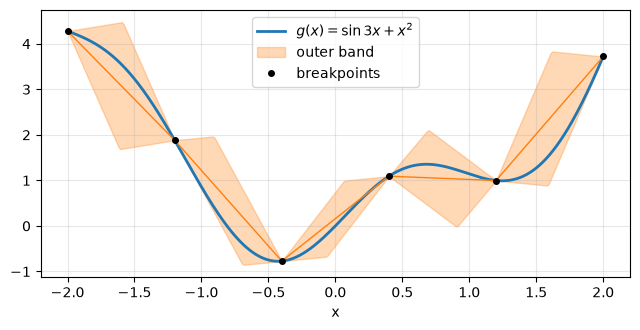

In [12]:
from discopt.modeling._pwl_transform import _segment_band, _Univariate

mm = dm.Model()
xx = mm.continuous("x", lb=-2.0, ub=2.0)
u = _Univariate(dm.sin(3 * xx) + xx**2, xx, -2.0, 2.0)
bps = np.linspace(-2.0, 2.0, 6)
pts = [u.point(float(t)) for t in bps]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
xs = np.linspace(-2, 2, 801)
ax.plot(xs, np.sin(3 * xs) + xs**2, color="C0", lw=2, label=r"$g(x)=\sin 3x + x^2$")
for i in range(5):
    a, b = float(bps[i]), float(bps[i + 1])
    bd = _segment_band(u, a, b, pts[i], pts[i + 1])
    seg = np.linspace(a, b, 60)
    r_ = (seg - a) / (b - a)
    chord = pts[i][0] + (pts[i + 1][0] - pts[i][0]) * r_
    ua, ka, ub_, kb, la, ja, lb_, jb = bd.taper
    upper = chord + np.minimum.reduce([np.full_like(r_, bd.hi), ua + ka * r_, ub_ + kb * (1 - r_)])
    lower = chord + np.maximum.reduce([np.full_like(r_, bd.lo), la + ja * r_, lb_ + jb * (1 - r_)])
    ax.fill_between(seg, lower, upper, color="C1", alpha=0.3, label="outer band" if i == 0 else None)
    ax.plot(seg, chord, color="C1", lw=1)
ax.plot(bps, [p[0] for p in pts], "ko", ms=4, label="breakpoints")
ax.set_xlabel("x"); ax.legend(loc="upper center"); ax.grid(alpha=0.3)
plt.tight_layout()

The band always contains the curve (that is the relaxation property, tested by dense
sampling in `python/tests/test_nonlinear_to_pwl.py`), and it narrows as segments
shrink.

First a smooth case. The objective below has two nonconvex univariate terms and a
linear coupling row; the outer mode turns it into a MILP and refines until the
verified incumbent meets the bound:

In [13]:
m = dm.Model("smooth")
x = m.continuous("x", lb=-2, ub=2)
y = m.continuous("y", lb=-1, ub=3)
m.minimize(x**4 - 3 * x**2 + x + dm.exp(0.5 * y) - y)
m.subject_to(x + y >= 0.5)

t = dm.nonlinear_to_pwl(m)
print(t)
r = t.solve(time_limit=120)
st = r.solver_stats["nonlinear_to_pwl"]
print(f"{r.status}  certified={r.gap_certified}  rounds={st['rounds']}")
print(f"objective = {r.objective:.6f}   bound = {r.bound:.6f}")
print(f"x = {r.value(x):.5f}, y = {r.value(y):.5f}")
r0 = m.solve()
print(f"discopt's own global solve: {r0.status}, objective {r0.objective:.6f}")

PWLTransformation(mode='outer', terms=2, skipped=0, fully_linear=True)


optimal  certified=True  rounds=9
objective = -2.855906   bound = -2.856142
x = -1.28514, y = 1.78514


discopt's own global solve: optimal, objective -2.855906


The bound comes from the MILP, the point is a verified point of the **original**
model, and the two meet — so `optimal` here is a certificate for the declared
problem, and it agrees with discopt's native global solve.

A harder case: economic dispatch with valve-point loading, the classic 3-unit
system of {cite:t}`Walters1993`. Each unit's cost is a quadratic plus a rectified
sine ripple, nonconvex and non-smooth, and univariate in that unit's output, so all
three costs are replaced (`example_valve_point_dispatch` in
`discopt.modeling.examples`). The `|sin|` kinks make the interval derivative
enclosure span both signs, so near a kink the band shrinks only linearly with the
segment width. With the default 20 refinement rounds (about 40 s here):

In [14]:
from discopt.modeling import examples
import contextlib, io

with contextlib.redirect_stdout(io.StringIO()):
    md_ = examples.example_valve_point_dispatch()
t = dm.nonlinear_to_pwl(md_, segments=8)
r = t.solve(time_limit=60)
P = next(v for v in md_._variables if v.name == "P")
st = r.solver_stats["nonlinear_to_pwl"]
print(f"{r.status}  certified={r.gap_certified}  rounds={st['rounds']}  "
      f"breakpoints per unit={[len(tt.breakpoints) for tt in t.terms]}")
print(f"cost = {r.objective:.3f}   bound = {r.bound:.3f}   gap = {100 * r.gap:.3f}%")
print(f"dispatch = {np.round(r.value(P), 3)}")
print(f"literature optimum 8234.07 lies inside [bound, cost]: {r.bound <= 8234.07 <= r.objective}")

feasible  certified=False  rounds=20  breakpoints per unit=[136, 119, 116]
cost = 8234.242   bound = 8154.074   gap = 0.974%
dispatch = [300.601 399.664 149.734]
literature optimum 8234.07 lies inside [bound, cost]: True


The rounds run out before the gap closes, and the result says exactly that: `feasible`,
not `optimal`, with a verified dispatch and a **valid** bound below the known
optimum. (Measured on this machine with `max_breakpoints=1000`: 41 rounds and
600 s reach a 0.19% gap with about 3000 breakpoints and 4.7 GB peak memory. The
default cap of 256 breakpoints per term keeps memory bounded; an earlier refinement
rule that bisected every wide segment doubled the table each round and was killed
for running out of memory.)

### `mode="approximate"`: the chord interpolant, never certified

This mode replaces each term by its interpolant through the breakpoint samples
(via `Model.piecewise`). The optimum of that surrogate is not a bound on anything,
so the result **never** carries one — whatever happens:

In [15]:
ra = dm.nonlinear_to_pwl(md_, mode="approximate", segments=8).solve(time_limit=120)
print(ra.status, "| bound:", ra.bound, "| certified:", ra.gap_certified)
print(f"verified cost of the approximate dispatch: {ra.objective:.4f}")
print(ra.algorithm_route)

feasible | bound: None | certified: False
verified cost of the approximate dispatch: 8343.9362
nonlinear_to_pwl(approximate): the model solved was a piecewise-linear APPROXIMATION of the one declared; no bound on the declared model is claimed


The status is `feasible` only if the approximate solution (or its local polish)
passes an independent feasibility check on the original model; otherwise it is
`local_infeasible`, which — as everywhere in discopt — is not an infeasibility proof.

### What it is good for, measured

`discopt_benchmarks/scripts/nonlinear_to_pwl_corpus_panel.py` runs the outer mode
over every in-repo corpus instance that has a reference optimum and a transformable
term, and checks the bound against that optimum:

21 corpus instances have at least one transformable term (60 s per instance,
4-core container):

| outcome (outer mode) | instances |
|---|---|
| `optimal`, certified — objective equals the reference | 10 (`mathopt5_2`, `nvs03`, `nvs04`, `nvs07`, `nvs15`, `st_miqp1`, `st_miqp3`, `st_test1`, `st_testgr3`, `trig`) |
| `feasible` — verified incumbent plus a valid bound, gap open | 4 (`ex8_1_1`, `nvs06`, `nvs09`, `nvs10`) |
| `time_limit` — valid bound, no verified incumbent yet | 7 (`nvs11`–`nvs13`, `nvs16`, `nvs17`, `nvs19`, `nvs24`) |
| bound above the reference optimum, or a wrong certified objective | **0** (31 executed checks) |

`discopt.solve()` on the same instances certified 19 of 21 within the same budget,
nearly all in under a second. The approximate mode, over the same instances, never
reported a bound or `optimal`, and no verified objective it reported beat the
reference optimum (40 executed checks, 0 violations).

The soundness result is the point: across the corpus no bound ever passed a reference
optimum and every certified objective matched it. The speed result is equally clear
and is recorded, not hidden: on these instances discopt's own spatial
branch-and-bound is **faster** — it builds rigorous relaxations of the same terms
without the partition binaries. `nonlinear_to_pwl` is the tool when you *want* a
MILP (to hand to a MILP workflow, to exploit a separable structure, or to trade
rigour knowingly with `mode="approximate"`), not a replacement for the default
solver.

Models with indicator, disjunctive, SOS, logical or complementarity relations are
refused (`PWLTransformError`): the incumbent check this transformation relies on
cannot verify those relations at a point.

## Summary

* `m.piecewise(x, breakpoints, values, method=..., name=...)` (or `dm.piecewise`)
  returns a variable equal to the declared piecewise-linear function of `x`.
* The lowering is exact, so solves are certified like any other MILP/MINLP.
* Four encodings; `"incremental"` is the measured default, `"log"` uses the fewest
  binaries, `"sos2"` keeps the SOS2 relation itself (slowest, and not exportable).
* The input's domain must lie inside the breakpoint span — refused loudly
  otherwise, at declaration and again at every solve.
* Univariate only; discontinuous (repeated-breakpoint) tables are refused — model
  jumps with `Model.either_or`.
* `dm.nonlinear_to_pwl` approximates univariate nonlinear terms: `mode="outer"` is a
  rigorous relaxation whose certificates are certificates of the original model;
  `mode="approximate"` never claims a bound.

Full citations are on the [References](../references.md) page.